# Segmentación interactiva con GrabCut

Este cuaderno presenta el algoritmo **GrabCut** para la segmentación interactiva de lesiones en imágenes de resonancia magnética cerebral.

El método se estudiará en dos etapas:

1. **Implementación didáctica:** se desarrollarán paso a paso los principales componentes matemáticos de GrabCut: modelo de mezclas gaussianas, costos de apariencia, coherencia espacial, construcción del grafo y corte mínimo.
2. **Implementación con OpenCV:** se utilizará `cv2.grabCut` para observar cómo estos pasos son encapsulados por una implementación optimizada.

Finalmente, ambas segmentaciones se compararán con una máscara de referencia mediante el **error cuadrático medio (ECM)**.

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Imagen de trabajo

Sea $x_i$ la intensidad del píxel $i$ de una imagen en escala de grises.

Para desarrollar el algoritmo se utilizará un único caso como ejemplo. Cada caso del conjunto de datos está identificado mediante la convención `VS-SEG-XXX`.

La imagen original se encuentra en:

```text
data/images/
```

Durante las siguientes secciones, esta imagen permitirá construir paso a paso los modelos probabilísticos y espaciales utilizados por GrabCut.

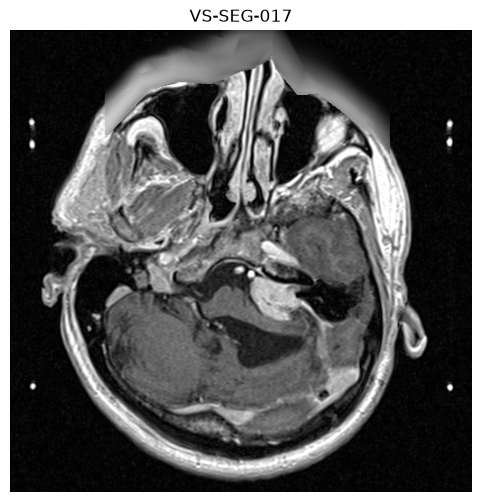

In [5]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

case_id = "VS-SEG-017"
image_path = DATA_DIR / "images" / f"{case_id}.png"

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title(case_id)
plt.axis("off")
plt.show()